# Pharmacies in Punjab (Pakistan): map and population density within 500 m

Workflow:
1. Map all pharmacies in Punjab (healthsites.io data, GADM boundaries) and export a 400 dpi JPEG.
2. Estimate population density (inhabitants/hectare) in a 500 m buffer around each pharmacy (WorldPop 100 m population counts) and plot a histogram (20 bins) with Q1, median and Q3 lines, exported as a 400 dpi JPEG.
3. Export pharmacies and buffers to a GeoPackage.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RAW, TEMP, OUT = ROOT / "data/raw", ROOT / "data/temp", ROOT / "data/output"
for d in (RAW, TEMP, OUT):
    d.mkdir(parents=True, exist_ok=True)

BUFFER_M = 500
WORKING_CRS = "EPSG:32643"   # WGS 84 / UTM 43N, metric CRS used for buffering and areas
DPI = 400

HS_DIR = RAW / "health-sites-io"   # manual download from healthsites.io (OSM extract: Pakistan-node.shp, Pakistan-way.shp)

# Local inputs, all read from data/raw/ (download them beforehand, see README for the sources)
RAW_FILES = {
    "GADM 4.1 boundaries": RAW / "gadm41_PAK.gpkg",
    "WorldPop population 100 m (2025)": RAW / "pak_pop_2025_CN_100m_R2025A_v1.tif",
    "Degree of Urbanisation L1 (2025)": RAW / "PAK_DUG_2025_GRID_L1_R2025A_v1.tif",
    "healthsites.io nodes": HS_DIR / "Pakistan-node.shp",
    "healthsites.io ways": HS_DIR / "Pakistan-way.shp",
}
DUG_CLASSES = {1: "Rural", 2: "Towns and suburbs (urban cluster)", 3: "Cities (urban centre)"}

## 0. Check raw inputs

All inputs are read from `data/raw/` (no download is done by the notebook).

In [2]:
missing = {k: v for k, v in RAW_FILES.items() if not v.exists() or v.stat().st_size == 0}
assert not missing, "Missing raw files in data/raw/:\n" + "\n".join(f"  {k}: {v}" for k, v in missing.items())
for k, v in RAW_FILES.items():
    print(f"found  {k}: {v.relative_to(ROOT)}")

found  GADM 4.1 boundaries: data/raw/gadm41_PAK.gpkg
found  WorldPop population 100 m (2025): data/raw/pak_pop_2025_CN_100m_R2025A_v1.tif
found  Degree of Urbanisation L1 (2025): data/raw/PAK_DUG_2025_GRID_L1_R2025A_v1.tif
found  healthsites.io nodes: data/raw/health-sites-io/Pakistan-node.shp
found  healthsites.io ways: data/raw/health-sites-io/Pakistan-way.shp


## 1. Punjab boundary and pharmacies

In [3]:
adm1 = gpd.read_file(RAW / "gadm41_PAK.gpkg", layer="ADM_ADM_1")
punjab = adm1[adm1["NAME_1"] == "Punjab"].to_crs(4326)
adm2 = gpd.read_file(RAW / "gadm41_PAK.gpkg", layer="ADM_ADM_2").to_crs(4326)
punjab_districts = adm2[adm2["NAME_1"] == "Punjab"]

# healthsites.io extract: points (OSM nodes) and building polygons (OSM ways)
# Shapefile field names are truncated to 10 characters (some collide), so only the needed fields are kept
HS_COLS = ["osm_id", "amenity", "healthcare", "name", "operator", "operator_t", "addr_stree", "addr_city", "geometry"]
hs = pd.concat([
    gpd.read_file(HS_DIR / "Pakistan-node.shp")[HS_COLS].assign(osm_type="node"),
    gpd.read_file(HS_DIR / "Pakistan-way.shp")[HS_COLS].assign(osm_type="way"),
], ignore_index=True)
hs = gpd.GeoDataFrame(hs, geometry="geometry", crs=4326)
print("all healthsites:", len(hs))

# A pharmacy is any site tagged amenity=pharmacy or healthcare=pharmacy
is_pharmacy = (hs["amenity"] == "pharmacy") | (hs["healthcare"] == "pharmacy")
pharm = hs[is_pharmacy].copy()
print("pharmacies in Pakistan:", len(pharm))

all healthsites: 4954
pharmacies in Pakistan: 874


In [4]:
# Quality checks: geometry type, missing/duplicate records
print(pharm.geom_type.value_counts().to_dict())
print("empty geometries:", pharm.geometry.is_empty.sum())
print("duplicate osm_type+osm_id:", pharm.duplicated(["osm_type", "osm_id"]).sum())

{'Point': 834, 'Polygon': 40}
empty geometries: 0
duplicate osm_type+osm_id: 0


In [5]:
# Non-point features (e.g. pharmacies mapped as building polygons) are represented by their centroid
pharm = pharm[~pharm.geometry.is_empty].copy()
pharm["geometry"] = pharm.to_crs(WORKING_CRS).centroid.to_crs(4326).where(~pharm.geom_type.eq("Point"), pharm.geometry)
pharm = pharm.drop_duplicates(["osm_type", "osm_id"])

# Keep pharmacies falling inside Punjab (spatial filter on the GADM polygon)
pharm = gpd.sjoin(pharm, punjab[["NAME_1", "geometry"]], how="inner", predicate="within").drop(columns=["index_right"])
pharm = pharm.rename(columns={"NAME_1": "province"})
# District attribution (GADM level 2)
pharm = gpd.sjoin(pharm, punjab_districts[["NAME_2", "geometry"]], how="left", predicate="within").drop(columns=["index_right"])
pharm = pharm.rename(columns={"NAME_2": "district"}).reset_index(drop=True)
pharm["pharmacy_id"] = np.arange(1, len(pharm) + 1)
print("pharmacies in Punjab:", len(pharm))
pharm.to_file(TEMP / "pharmacies_punjab.gpkg", layer="pharmacies", driver="GPKG")
pharm[["pharmacy_id", "name", "district", "operator_t", "geometry"]].head()

pharmacies in Punjab: 242


,pharmacy_id,name,district,operator_t,geometry
0,1,ڈی واٹسن کیمسٹ,Rawalpindi,NaN,POINT (73.07169 33.63215)
1,2,Ahmad Din Pharmacy,Lahore,NaN,POINT (74.25115 31.61064)
2,3,Fazal Din Pharmacy,Lahore,NaN,POINT (74.31652 31.46753)
3,4,CMH Pharmacy,Bahawalpur,NaN,POINT (71.68328 29.37111)
4,5,Fazal Din Pharmacy,Lahore,NaN,POINT (74.34655 31.52378)


### 1bis. Map of pharmacies on the Degree of Urbanisation (JPEG, 400 dpi)

The 1 km Degree of Urbanisation grid (Mollweide) is reprojected to WGS 84 with nearest-neighbour resampling, clipped to Punjab and used as background.

In [6]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib.patheffects as pe
from rasterio.features import geometry_mask
from rasterio.transform import from_origin
from rasterio.warp import reproject, Resampling

# Reproject DUG L1 (ESRI:54009) onto a regular lon/lat grid covering Punjab
minx, miny, maxx, maxy = punjab.total_bounds
res = 0.005
w, h = int(np.ceil((maxx - minx) / res)), int(np.ceil((maxy - miny) / res))
dst_transform = from_origin(minx, maxy, res, res)
dug = np.zeros((h, w), dtype="uint8")
with rasterio.open(RAW / "PAK_DUG_2025_GRID_L1_R2025A_v1.tif") as src:
    reproject(rasterio.band(src, 1), dug, dst_transform=dst_transform, dst_crs="EPSG:4326", resampling=Resampling.nearest)
outside = geometry_mask(punjab.geometry, out_shape=dug.shape, transform=dst_transform, invert=False)
dug = np.ma.masked_where(outside | (dug == 0), dug)
print({DUG_CLASSES[k]: int((dug == k).sum()) for k in DUG_CLASSES}, "(pixels)")

{'Rural': 462564, 'Towns and suburbs (urban cluster)': 285115, 'Cities (urban centre)': 25213} (pixels)


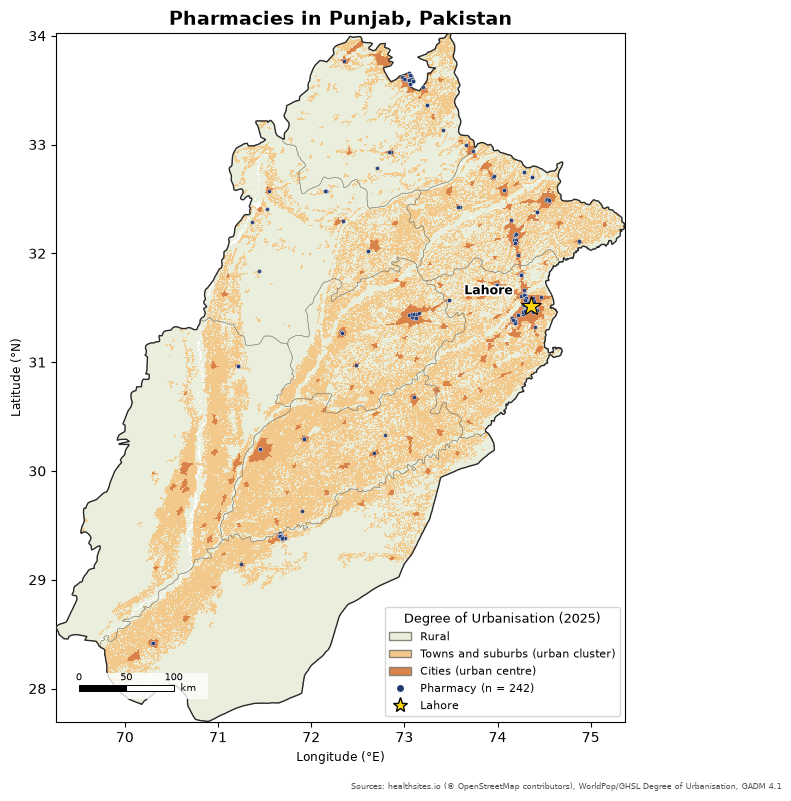

In [7]:
LAHORE = (74.3587, 31.5204)   # lon, lat of Lahore city centre
dug_colors = {1: "#e9efdc", 2: "#f3c98b", 3: "#d9824a"}
cmap = ListedColormap([dug_colors[k] for k in (1, 2, 3)])
extent = (minx, minx + w * res, maxy - h * res, maxy)

def add_scale_bar(ax, length_km=100, n_seg=2, x_frac=0.04, y_frac=0.045, height_frac=0.008):
    # Alternating black/white scale bar in km, bottom-left of a lon/lat axes.
    # Length is exact at the latitude where the bar is drawn (1 deg lon = 111.32 km * cos(lat)).
    x0_ax, x1_ax = ax.get_xlim(); y0_ax, y1_ax = ax.get_ylim()
    x0, y0 = x0_ax + x_frac * (x1_ax - x0_ax), y0_ax + y_frac * (y1_ax - y0_ax)
    deg_per_km = 1 / (111.32 * np.cos(np.radians(y0)))
    seg = length_km / n_seg
    hgt = height_frac * (y1_ax - y0_ax)
    pad_x, pad_y = 0.015 * (x1_ax - x0_ax), 0.012 * (y1_ax - y0_ax)   # translucent white backing for legibility
    ax.add_patch(plt.Rectangle((x0 - pad_x, y0 - pad_y), length_km * deg_per_km + 5 * pad_x, hgt + 0.03 * (y1_ax - y0_ax),
                               facecolor="white", edgecolor="none", alpha=0.8, zorder=9))
    for i in range(n_seg):
        ax.add_patch(plt.Rectangle((x0 + i * seg * deg_per_km, y0), seg * deg_per_km, hgt, facecolor="black" if i % 2 == 0 else "white",
                                   edgecolor="black", linewidth=0.7, zorder=10))
    for i in range(n_seg + 1):
        ax.text(x0 + i * seg * deg_per_km, y0 + hgt + 0.004 * (y1_ax - y0_ax), f"{i * seg:g}", ha="center", va="bottom", fontsize=7, zorder=10)
    ax.text(x0 + length_km * deg_per_km + 0.012 * (x1_ax - x0_ax), y0 + hgt / 2, "km", ha="left", va="center", fontsize=7, zorder=10)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(dug, cmap=cmap, vmin=0.5, vmax=3.5, extent=extent, interpolation="nearest", zorder=1)
punjab_districts.boundary.plot(ax=ax, color="#8a8578", linewidth=0.35, zorder=2)
punjab.boundary.plot(ax=ax, color="#2b2b2b", linewidth=1.0, zorder=3)
pharm.plot(ax=ax, color="#1f3b73", edgecolor="white", linewidth=0.3, markersize=9, alpha=0.9, zorder=4)
handles = [Patch(facecolor=dug_colors[k], edgecolor="#8a8578", label=DUG_CLASSES[k]) for k in (1, 2, 3)]
handles.append(plt.Line2D([], [], marker="o", ls="", markerfacecolor="#1f3b73", markeredgecolor="white", markersize=6, label=f"Pharmacy (n = {len(pharm)})"))
handles.append(plt.Line2D([], [], marker="*", ls="", markerfacecolor="#ffd60a", markeredgecolor="black", markersize=11, label="Lahore"))
ax.legend(handles=handles, title="Degree of Urbanisation (2025)", loc="lower right", frameon=True, fontsize=8, title_fontsize=9)
ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
add_scale_bar(ax, length_km=100)
ax.plot(*LAHORE, marker="*", ls="", markersize=15, markerfacecolor="#ffd60a", markeredgecolor="black", markeredgewidth=0.8, zorder=8)
ax.annotate("Lahore", LAHORE, xytext=(-12, 6), textcoords="offset points", ha="right", va="bottom", fontsize=9, weight="bold",
            zorder=8, path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
ax.set_title("Pharmacies in Punjab, Pakistan", fontsize=14, weight="bold")
ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
plt.tight_layout(rect=(0, 0.02, 1, 1))
fig.text(0.99, 0.005, "Sources: healthsites.io (© OpenStreetMap contributors), WorldPop/GHSL Degree of Urbanisation, GADM 4.1",
         ha="right", va="bottom", fontsize=6, color="#555")
fig.savefig(OUT / "map_pharmacies_punjab.jpeg", dpi=DPI, format="jpeg", pil_kwargs={"quality": 95})
plt.show()

## 2. Population density within 500 m of each pharmacy

Buffers are built in a metric CRS (UTM 43N), then sent back to WGS 84 to sum WorldPop 100 m pixels (people per pixel) whose centre falls inside the buffer. Density = people in buffer / buffer area in hectares (1 ha = 10,000 m²).

In [8]:
pharm_m = pharm.to_crs(WORKING_CRS)
buffers = gpd.GeoDataFrame(pharm_m[["pharmacy_id", "name", "district"]].copy(),
                           geometry=pharm_m.geometry.buffer(BUFFER_M, quad_segs=32), crs=WORKING_CRS)
buffers["buffer_area_ha"] = buffers.geometry.area / 10_000
buffers = buffers.to_crs(4326)
print("buffer area (ha), min/max:", buffers.buffer_area_ha.min().round(2), buffers.buffer_area_ha.max().round(2))

buffer area (ha), min/max: 78.51 78.51


In [9]:
RASTER = RAW / "pak_pop_2025_CN_100m_R2025A_v1.tif"
pop_sum, n_pix = [], []
with rasterio.open(RASTER) as src:   # windowed read per buffer keeps memory low (the full raster is ~1.3 GB in memory)
    for geom in buffers.geometry:
        arr, _ = mask(src, [geom], crop=True, all_touched=False, nodata=src.nodata, filled=False)
        valid = arr.compressed()
        pop_sum.append(float(valid.sum()) if valid.size else 0.0)
        n_pix.append(int(valid.size))
buffers["pop_sum"] = pop_sum
buffers["n_pixels"] = n_pix
buffers["density_hab_ha"] = buffers["pop_sum"] / buffers["buffer_area_ha"]
buffers.drop(columns="geometry").to_csv(TEMP / "pharmacy_density.csv", index=False)
buffers["density_hab_ha"].describe()

count    242.000000
mean     228.396785
std      107.474263
min        9.776218
25%      133.821538
50%      243.108766
75%      318.448949
max      433.275364
Name: density_hab_ha, dtype: float64

In [10]:
# Join density back to pharmacy points
pharm = pharm.merge(buffers[["pharmacy_id", "buffer_area_ha", "pop_sum", "n_pixels", "density_hab_ha"]], on="pharmacy_id")
print("buffers with fewer than 60 valid pixels (edge/nodata):", (buffers.n_pixels < 60).sum())

buffers with fewer than 60 valid pixels (edge/nodata): 0


### 2bis. Histogram of population density (20 bins; Q1, median, Q3)

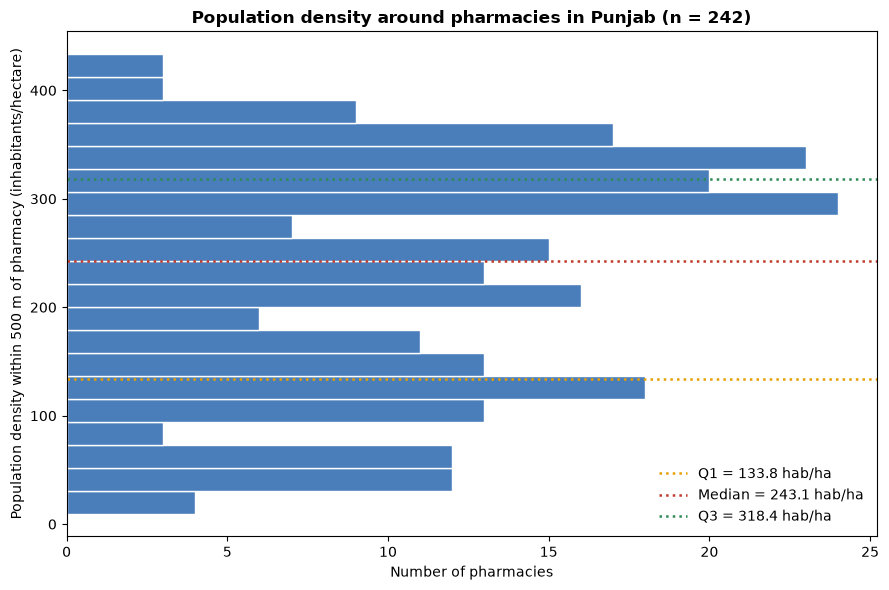

Q1 = 133.82, median = 243.11, Q3 = 318.45 hab/ha


In [11]:
d = pharm["density_hab_ha"]
q1, med, q3 = d.quantile([0.25, 0.5, 0.75])

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(d, bins=20, orientation="horizontal", color="#4a7ebb", edgecolor="white")
for val, lab, c in [(q1, "Q1", "#e69f00"), (med, "Median", "#c0392b"), (q3, "Q3", "#2e8b57")]:
    ax.axhline(val, ls=":", lw=1.8, color=c, label=f"{lab} = {val:.1f} hab/ha")
ax.set_ylabel("Population density within 500 m of pharmacy (inhabitants/hectare)")
ax.set_xlabel("Number of pharmacies")
ax.set_title(f"Population density around pharmacies in Punjab (n = {len(d)})", weight="bold")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
fig.savefig(OUT / "hist_density_pharmacies_punjab.jpeg", dpi=DPI, format="jpeg", pil_kwargs={"quality": 95})
plt.show()
print(f"Q1 = {q1:.2f}, median = {med:.2f}, Q3 = {q3:.2f} hab/ha")

> Bars are horizontal (density on the *y* axis), so the horizontal dotted lines mark Q1, median and Q3 directly on the density scale.

## 3. Export to GeoPackage

In [12]:
gpkg = OUT / "pharmacies_punjab_buffers.gpkg"
gpkg.unlink(missing_ok=True)
keep = ["pharmacy_id", "osm_type", "osm_id", "name", "operator_t", "district", "province",
        "pop_sum", "buffer_area_ha", "density_hab_ha", "geometry"]
pharm[keep].to_file(gpkg, layer="pharmacies", driver="GPKG")
buffers[["pharmacy_id", "name", "district", "buffer_area_ha", "pop_sum", "density_hab_ha", "geometry"]].to_file(gpkg, layer="buffers_500m", driver="GPKG")
print(gpd.list_layers(gpkg))

           name geometry_type
0    pharmacies         Point
1  buffers_500m       Polygon
